<a href="https://colab.research.google.com/github/giraldoal/datos12024/blob/main/Ejercicio_de_aplicaci%C3%B3n_archivos_de_texto_plano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El Proyecto Gutenberg


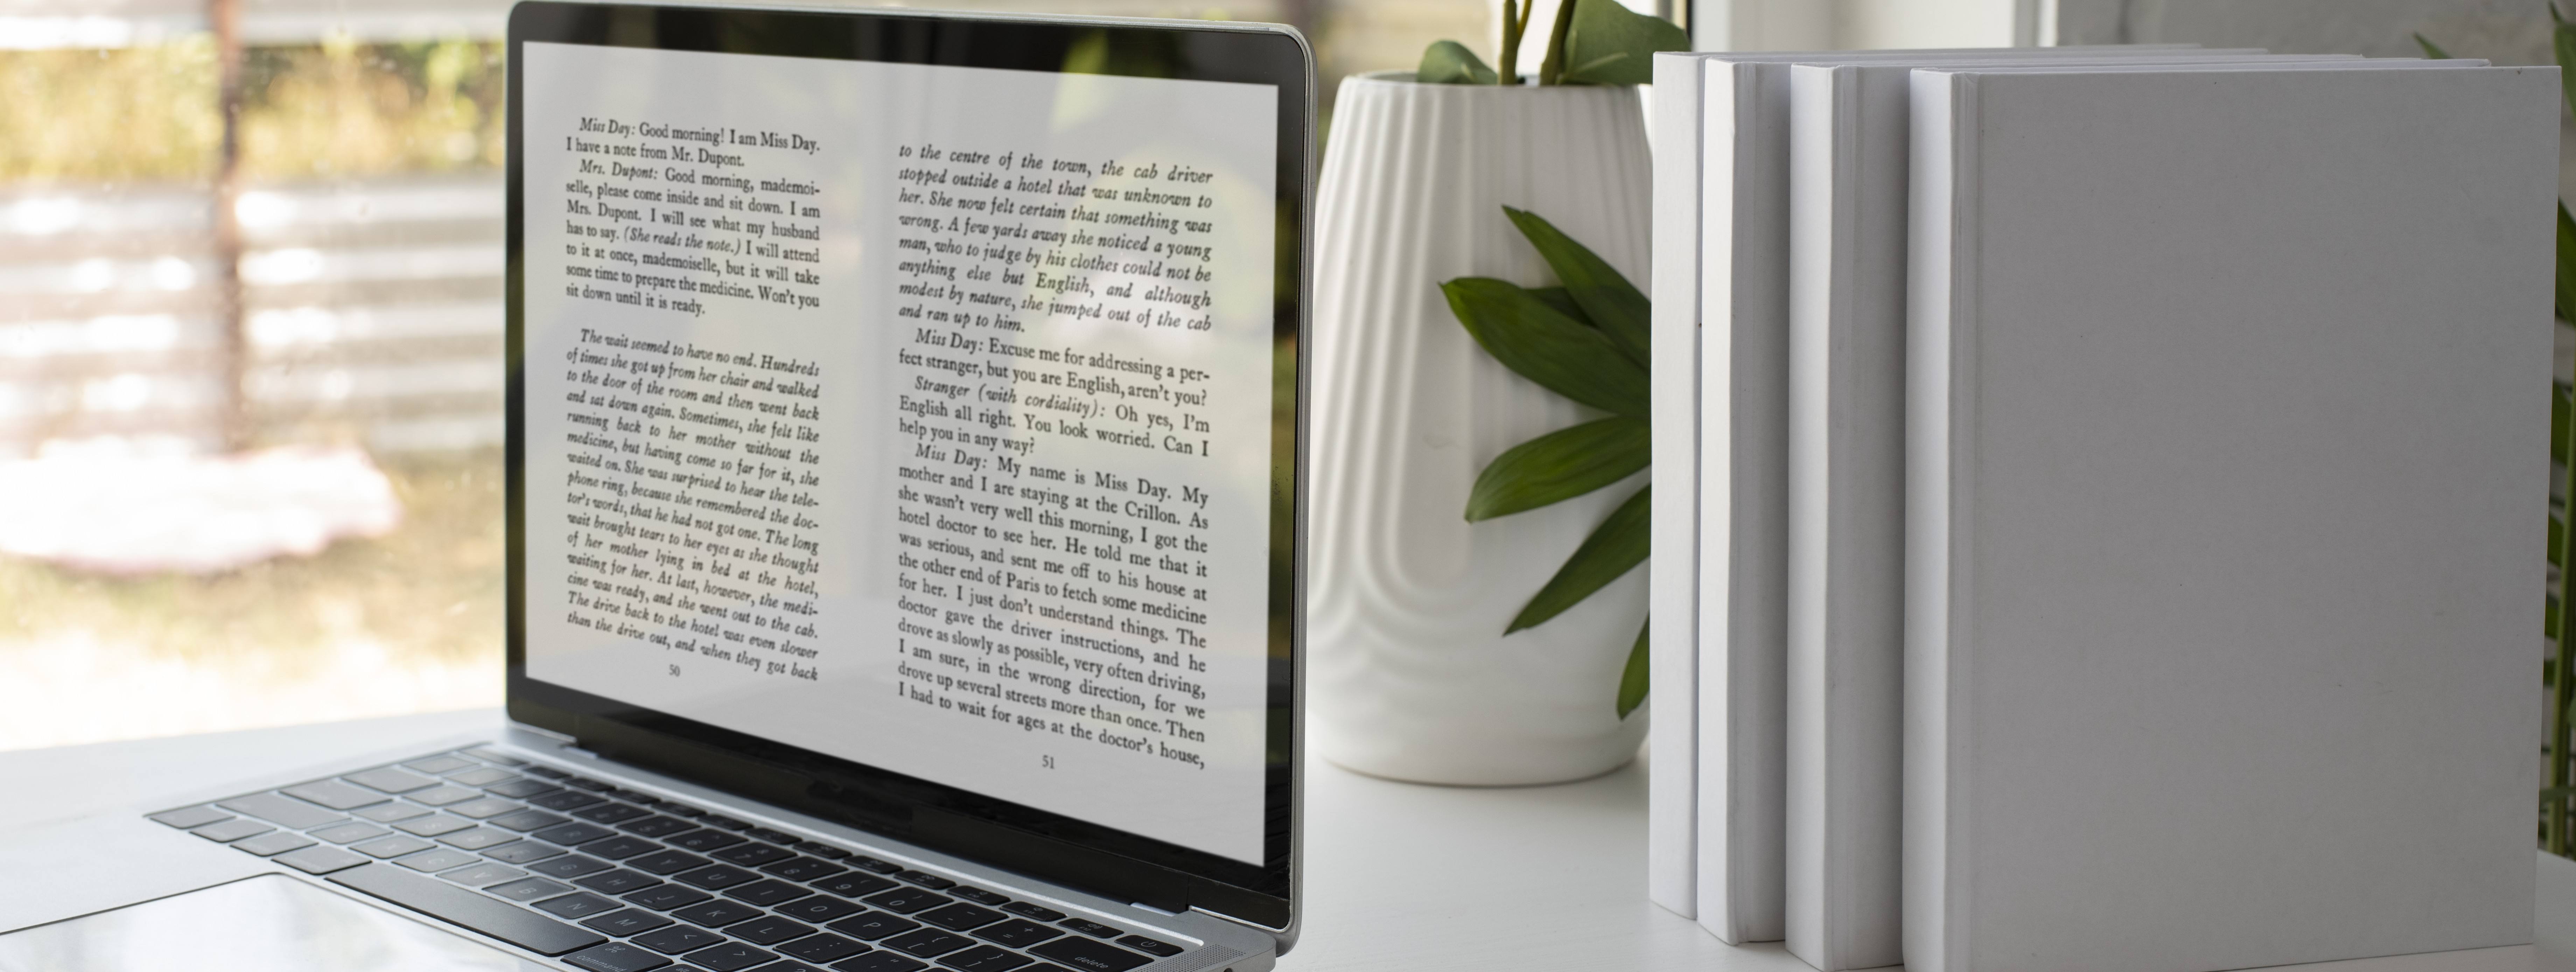

El [Proyecto Gutenberg](https://www.gutenberg.org/) es una biblioteca en línea de libros electrónicos gratuitos, fue el primer proveedor de libros electrónicos gratuitos, o eBooks. Michael Hart, fundador del Proyecto Gutenberg, inventó los libros electrónicos en 1971 y su memoria sigue inspirando hoy la creación de libros electrónicos y contenidos afines.

Para este ejemplo utilizaremos el libro **"[Novelas Cortas](https://www.gutenberg.org/ebooks/15532)"** por Pedro Antonio de Alarcón. Nuestro objetivo es obtener una tabla de datos en formato CSV con el vocabulario utilizado en español definido en idioma al inglés.

## Descarga de datos

In [ ]:
#@markdown 1. Descargamos el archivo de texto del libro, el cual tiene el nombre `pg15532.txt`.
!wget https://www.gutenberg.org/cache/epub/15532/pg15532.txt

--2026-03-30 06:26:13--  https://www.gutenberg.org/cache/epub/15532/pg15532.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 474866 (464K) [text/plain]
Saving to: ‘pg15532.txt’

pg15532.txt         100%[===================>] 463.74K  2.54MB/s    in 0.2s    

2026-03-30 06:26:13 (2.54 MB/s) - ‘pg15532.txt’ saved [474866/474866]



## Extracción de datos

1. Las lineas que nos interesan tienen el siguiente patrón:
- Inicia por =
- Palabra en español
- Finaliza la palabra en español con =
- Da la aproximación en ingles de la palabra en español

Por lo tanto, tenemos el siguiente código para crear el patrón requerido:

In [ ]:
import re
patron = re.compile(r"^=[a-zA-ZáéíóúÁÉÍÓÚüÜñÑ]+=.+")

La expresión regular `^=[a-zA-ZáéíóúÁÉÍÓÚüÜñÑ]+=.+` se puede entender como:

- `^=`: indica que la línea debe comenzar con un signo igual (=).
- `[a-zA-ZáéíóúÁÉÍÓÚüÜñÑ]+`: busca una o más letras en español, mayúsculas o minúsculas.
- `=`: busca otro signo igual (=).
- `.+`: busca cualquier caracter (excepto saltos de línea) cero o más veces.

2. Leeremos el archivo de texto linea a linea y extraemos aquellas lineas que coinciden con vocabulario.

In [ ]:
datos_extraidos = []
with open("pg15532.txt",'r') as f:
  for line in f.readlines():
    line = line.strip()
    resultado = patron.search( line )
    if resultado == None:
      continue
    # Siempre que se halle coincidencia se
    # agrega la linea al vocabulario
    datos_extraidos.append(line)
print("Palabras halladas:", len(datos_extraidos))


Palabras halladas: 3450


## Transformación

En las lineas de vocabulario, hay casos en los que se especifican composiciones de palabras, aquellos casos en que no hay palabras compuestas se finaliza con un punto, en el caso en que se especifican composiciones se agregan finalizando la primera parte con ';', y luego inicia con un '='.

En la tabla resultante se almacenan los pares palabra y definición en inglés:

In [ ]:
# Creamos el patrón para extraer la palabra y su definición

patron = re.compile(r"^=([a-zA-ZáéíóúÁÉÍÓÚüÜñÑ]+)=([^=]+)|^=([a-zA-ZáéíóúÁÉÍÓÚüÜñÑ]+)=(.+)=.+")

datos_transformados=[]
for v in datos_extraidos:
  resultado = patron.search( v )
  if resultado == None:
    print("Patron incorrecto:", v)
    continue
  # Siempre que se halle coincidencia se
  # agrega la linea al vocabulario
  palabra = resultado.group(1)
  definicion = resultado.group(2)
  datos_transformados.append([palabra, definicion])

print("Cantidad de palabras:", len(datos_transformados))


Cantidad de palabras: 3450


Se transforman los datos a un dataframe:

In [ ]:
import pandas as pd
df= pd.DataFrame(datos_transformados)
df.columns = ["Palabra", "Inglés"]
df

,Palabra,Inglés
0,a,"to, at."
1,abajo,"under, down, downstairs."
2,abandonar,to abandon.
3,abastecer,"to purvey, supply."
4,abasto,provisions.
...,...,...
3445,zalema,"salaam, bow."
3446,zapatilla,pump (shoe).
3447,zócalo,"socle, base."
3448,zona,zone.


## Carga de datos
Finalmente se guardan los datos en el archivo "vocabulario.csv":

In [ ]:
df.to_csv("vocabulario.csv")